# Notebook 02.2 — Imputação de Classes Viárias via Redes Neurais em Grafos (GNN)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — Pipeline AE2SFCA  
**Autor:** Felipe Ramos Dantas  
**Programa:** MAPEPROF / IFPI  

---
## Objetivo
A base da Overture Maps frequentemente possui segmentos viários com classificação desconhecida (`unknown` ou `unclassified`), o que impossibilita a atribuição de velocidades médias e inviabiliza o cálculo de tempo de viagem. 

Este notebook resolve esse problema utilizando **Inteligência Artificial (Redes Neurais em Grafos - GNN)**. O modelo aprende os padrões das ruas já classificadas e prevê as classes faltantes usando:
1. **Atributos Geométricos (Morfologia):** Comprimento e Linearidade.
2. **Atributos Físicos:** Superfície (pavimentada ou terra).
3. **Contexto Topológico (Grafo Dual):** A premissa de que "uma rua desconhecida conectada a duas vias arteriais provavelmente também é uma via arterial ou coletora".

---

Este notebook soluciona o problema de segmentos viários sem classificação hierárquica (*unknown*) provenientes da Overture Maps. A classificação correta é imprescindível para a atribuição de velocidades no modelo AE2SFCA.

Para esta tarefa, adotamos uma **Rede Neural em Grafos (GNN - GraphSAGE)**. Para garantir a robustez e eficiência da modelagem, utilizamos nativamente a API da biblioteca `city2graph`:
* **`city2graph.morphology`**: Para enriquecer a via com atributos físicos.
* **`city2graph.graph`**: Para gerar a topologia do Grafo Primal base.
* **`city2graph.utils`**: Para a conversão otimizada da topologia para o formato tensorial do PyTorch Geometric.

In [1]:
# ── Bibliotecas Essenciais ──────────────────────────────────────────────────
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import itertools
from tqdm.auto import tqdm

# ── API City2Graph (Módulos REAIS) ──────────────────────────────────────────
import city2graph as c2g
import city2graph.morphology as c2g_morpho
import city2graph.utils as c2g_utils

import matplotlib.pyplot as plt

# ── Machine Learning e GNN ──────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv # Utilizando a GCN documentada na dissertação
from torch_geometric.utils import from_networkx
from torch_geometric.data import Data

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'serif'})
warnings.filterwarnings("ignore")
tqdm.pandas()

PROCESSED_PATH = Path('../dados/processados')
FIGURAS_PATH = Path('../outputs/figuras/nb022')
FIGURAS_PATH.mkdir(parents=True, exist_ok=True)

# Definição de Dispositivo (GPU/CPU) para a Inteligência Artificial
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Setup concluído. Computação em: {device}")

✅ Setup concluído. Computação em: cpu


In [2]:
# ── 1. Carregamento e Preparação de Features (X) ────────────────────────────
print("🔄 Carregando malha limpa do Notebook 02.1...")
gdf_roads = gpd.read_file(PROCESSED_PATH / "zonaUrbanaReal_5km_road_cleaned.geojson")

print("📏 Extraindo atributos espaciais...")
gdf_roads['length_m'] = gdf_roads.geometry.length
gdf_roads['linearity'] = gdf_roads['linearity'].fillna(1.0)
gdf_roads['is_paved'] = gdf_roads['road_surface'].apply(lambda x: 1 if x == 'paved' else 0)

# ── Separação do que é Treino (Conhecido) e Predição (Desconhecido) ─────────
classes_invalidas = ['unknown', 'unclassified', None, '']
gdf_roads['is_unknown'] = gdf_roads['classe_original'].isin(classes_invalidas)

# Padronização SÓ para a rede neural, em um array separado.
# Não sobrescreve length_m nem linearity, que seguem em metros para o NB 03.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(gdf_roads[['length_m', 'linearity']])

print(f"📊 Ruas com classe conhecida (Treino): {(~gdf_roads['is_unknown']).sum():,}")
print(f"❓ Ruas sem classificação (Alvo da IA): {gdf_roads['is_unknown'].sum():,}")

🔄 Carregando malha limpa do Notebook 02.1...
📏 Extraindo atributos espaciais...
📊 Ruas com classe conhecida (Treino): 50,928
❓ Ruas sem classificação (Alvo da IA): 1,503


## 2.1 Codificação Semântica e Vetorização (Features)
A Inteligência Artificial compreende apenas matrizes numéricas. Nesta etapa, traduzimos as classes textuais da Overture Maps (ex: *'residential'*, *'primary'*) para identificadores numéricos inteiros (0, 1, 2...). Em seguida, agrupamos as características geométricas e físicas da via em um único vetor matemático ($X$), que será o material de estudo da Rede Neural.

In [3]:
print("🔢 Codificando classes textuais para formato numérico...")

# 1. Instancia o codificador e aprende as classes que existem
encoder = LabelEncoder()
classes_conhecidas = gdf_roads.loc[~gdf_roads['is_unknown'], 'classe_original']
encoder.fit(classes_conhecidas)

# 2. Aplica a tradução numérica (-1 será nosso marcador para 'rua desconhecida')
gdf_roads['class_encoded'] = -1
mascara_conhecidos = ~gdf_roads['is_unknown']
gdf_roads.loc[mascara_conhecidos, 'class_encoded'] = encoder.transform(gdf_roads.loc[mascara_conhecidos, 'classe_original'])

# 3. Extração das Features (X) e Targets (Y) para o formato de matriz (Numpy)
# Contínuas padronizadas (X_scaled) + is_paved (já 0/1)
x_features = np.column_stack([X_scaled, gdf_roads['is_paved'].values])
y_targets = gdf_roads['class_encoded'].values
mascara_treino = (~gdf_roads['is_unknown']).values

print(f"✅ Vetorização concluída. {len(encoder.classes_)} classes únicas identificadas.")

🔢 Codificando classes textuais para formato numérico...
✅ Vetorização concluída. 13 classes únicas identificadas.


## 2.2 Modelagem Topológica Base: O Grafo Primal
O primeiro passo estrutural é ler o `GeoDataFrame` e representá-lo como uma rede de transportes clássica, gerando o **Grafo Primal**. Nele, as esquinas funcionam como os nós de conexão e os trechos de asfalto como as arestas. Utilizamos o módulo `morphology` da biblioteca `city2graph` para garantir que a topologia extraída no notebook anterior seja preservada matematicamente.

In [4]:
print("🕸️ Gerando o Grafo Primal (Esquinas = Nós | Ruas = Arestas)...")

# 🚨 SOLUÇÃO DE INTEGRIDADE: 
# Como as vias foram particionadas no NB 02.1, os IDs originais da Overture estão duplicados.
# Criamos um identificador matemático estritamente único para cada fragmento de rua.
gdf_roads['id_unico_aresta'] = [f"aresta_{i}" for i in range(len(gdf_roads))]

# Usa a API nativa para converter a tabela de ruas em um grafo NetworkX
G_primal = c2g_morpho.segments_to_graph(gdf_roads, multigraph=True, as_nx=True)

print(f"✅ Grafo Primal gerado: {G_primal.number_of_nodes():,} nós topológicos (esquinas) e {G_primal.number_of_edges():,} arestas viárias.")

Removed 36 invalid geometries


🕸️ Gerando o Grafo Primal (Esquinas = Nós | Ruas = Arestas)...
✅ Grafo Primal gerado: 34,781 nós topológicos (esquinas) e 52,091 arestas viárias.


## 2.3 Transmutação Espacial: O Grafo Dual (Line Graph)
Como a arquitetura *GraphSAGE* requer que o alvo da previsão seja um nó (*Node Classification*), realizamos a inversão topológica. Utilizando o módulo `utils` do `city2graph`, transformamos o Grafo Primal em um **Grafo Dual**. Agora, as ruas se tornaram os "nós", e as esquinas se tornaram as "arestas" que ligam esses nós, permitindo que a IA avalie a vizinhança semântica de cada via.

In [5]:
print("🔄 Invertendo a topologia para o Grafo Dual (Line Graph)...")

# Usa a API nativa para inverter o grafo, usando o NOVO ID ÚNICO como chave
G_dual = c2g_utils.dual_graph(G_primal, edge_id_col='id_unico_aresta', as_nx=True)

print(f"✅ Grafo Dual gerado! Agora temos {G_dual.number_of_nodes():,} nós (que representam os fragmentos de rua).")

🔄 Invertendo a topologia para o Grafo Dual (Line Graph)...
✅ Grafo Dual gerado! Agora temos 52,091 nós (que representam os fragmentos de rua).


## 2.4 Alinhamento e Instanciação Tensorial (PyTorch Geometric)
Com a topologia dual validada, a última etapa de preparação consiste em alinhar rigorosamente as posições dos nós do grafo com as matrizes de atributos ($X$) e de classificação ($Y$). Por fim, convertemos o grafo da biblioteca `NetworkX` para a estrutura de alta performance `Data` exigida pelo `PyTorch Geometric`, enviando os cálculos para a memória da GPU (ou CPU).

In [6]:
print("🧠 Instanciando tensores e o objeto Data para o PyTorch...")

# 1. Garante que os nós tenham índices inteiros limpos e sequenciais para a matriz
G_ordenado = nx.convert_node_labels_to_integers(G_dual, ordering='sorted')

# 2. Isola estritamente as adjacências (quem liga com quem) para evitar conflitos de metadados
G_topology_only = nx.Graph()
G_topology_only.add_nodes_from(G_ordenado.nodes()) 
G_topology_only.add_edges_from(G_ordenado.edges()) 

# 3. Converte as adjacências do NetworkX para o PyTorch (edge_index)
pyg_graph = from_networkx(G_topology_only)
edge_index = pyg_graph.edge_index.to(device)

# 4. Converte nossas matrizes NumPy em Tensores do PyTorch
x_tensor = torch.tensor(x_features, dtype=torch.float).to(device)
y_tensor = torch.tensor(y_targets, dtype=torch.long).to(device)
train_mask_tensor = torch.tensor(mascara_treino, dtype=torch.bool).to(device)

# 5. Monta o Objeto 'Data' final, a "caixa" que será entregue à Inteligência Artificial
pyg_data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
pyg_data.train_mask = train_mask_tensor

print("✅ Pipeline topológico 100% concluído!")
print(f"   -> Tensores instanciados em: {device}")
print(f"   -> Estrutura final: {pyg_data}")

🧠 Instanciando tensores e o objeto Data para o PyTorch...
✅ Pipeline topológico 100% concluído!
   -> Tensores instanciados em: cpu
   -> Estrutura final: Data(x=[52431, 3], edge_index=[2, 234636], y=[52431], train_mask=[52431])


In [7]:
# ── CÉLULA 5: Arquitetura GCN, Balanceamento e Grid Search ──────────────────

# 1. Definição da Arquitetura GCN
class StreetClassifier(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# 2. Pesos de Classe (Evita que a IA classifique tudo como 'residential')
indices_conhecidos = pyg_data.train_mask.nonzero(as_tuple=True)[0].cpu().numpy()
labels_conhecidos = pyg_data.y[indices_conhecidos].cpu().numpy()

pesos_balanceados = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(labels_conhecidos), 
    y=labels_conhecidos
)
pesos_tensor = torch.tensor(pesos_balanceados, dtype=torch.float).to(device)

# 3. Grid Search (Para gerar a tabela da Figura 3 da dissertação)
print("🔍 Executando Grid Search da GCN...")

idx_train, idx_val = train_test_split(
    indices_conhecidos, test_size=0.20, random_state=42, stratify=labels_conhecidos
)

train_mask_search = torch.zeros_like(pyg_data.y, dtype=torch.bool)
train_mask_search[idx_train] = True
val_mask_search = torch.zeros_like(pyg_data.y, dtype=torch.bool)
val_mask_search[idx_val] = True

param_grid = {
    'hidden_channels': [16, 32, 64], 
    'lr': [0.01, 0.005],             
    'weight_decay': [5e-4, 1e-4]
}

keys, values = zip(*param_grid.items())
combinacoes = [dict(zip(keys, v)) for v in itertools.product(*values)]
resultados = []

for params in tqdm(combinacoes, desc="Avaliando Hiperparâmetros"):
    model = StreetClassifier(
        num_features=pyg_data.num_node_features, 
        num_classes=len(encoder.classes_),
        hidden_channels=params['hidden_channels']
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    
    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        out = model(pyg_data.x, pyg_data.edge_index)
        loss = F.nll_loss(out[train_mask_search], pyg_data.y[train_mask_search], weight=pesos_tensor)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        out = model(pyg_data.x, pyg_data.edge_index)
        pred = out.argmax(dim=1)
        correct = (pred[val_mask_search] == pyg_data.y[val_mask_search]).sum()
        acc = int(correct) / int(val_mask_search.sum())
    
    res = params.copy()
    res['accuracy'] = acc
    resultados.append(res)

df_results = pd.DataFrame(resultados)
melhor_config = df_results.loc[df_results['accuracy'].idxmax()]

print("\n🏆 Configuração Vencedora:")
print(melhor_config)

# 4. Treinamento Final com a Melhor Configuração
print(f"\n🧠 Treinando GCN final com {melhor_config['hidden_channels']} neurônios...")
model_final = StreetClassifier(
    num_features=pyg_data.num_node_features, 
    num_classes=len(encoder.classes_),
    hidden_channels=int(melhor_config['hidden_channels'])
).to(device)

optimizer = torch.optim.Adam(model_final.parameters(), lr=melhor_config['lr'], weight_decay=melhor_config['weight_decay'])

model_final.train()
for epoch in tqdm(range(300), desc="Treinamento Definitivo"):
    optimizer.zero_grad()
    out = model_final(pyg_data.x, pyg_data.edge_index)
    loss = F.nll_loss(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask], weight=pesos_tensor)
    loss.backward()
    optimizer.step()

🔍 Executando Grid Search da GCN...


Avaliando Hiperparâmetros: 100%|██████████| 12/12 [03:46<00:00, 18.87s/it]



🏆 Configuração Vencedora:
hidden_channels    16.000000
lr                  0.005000
weight_decay        0.000100
accuracy            0.322796
Name: 3, dtype: float64

🧠 Treinando GCN final com 16.0 neurônios...


Treinamento Definitivo: 100%|██████████| 300/300 [00:15<00:00, 18.93it/s]


# ── 3. Treinamento da Inteligência Artificial (GraphSAGE) ───────────────────
class RoadSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(RoadSAGE, self).__init__()
        # A convolução GraphSAGE aprende com as ruas vizinhas
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x) # Função de ativação não-linear
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# Inicializa o modelo
model = RoadSAGE(in_channels=3, hidden_channels=16, out_channels=len(encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

print("🧠 Iniciando o Treinamento da Rede Neural...")
model.train()

# Loop de treinamento com feedback visual do progresso (A Barra Visual)
for epoch in tqdm(range(1, 201), desc="Treinando GNN (GraphSAGE)"):
    optimizer.zero_grad()
    out = model(pyg_data.x, pyg_data.edge_index)
    
    # O modelo calcula o erro apenas nas vias onde sabemos a classe real (train_mask)
    loss = F.nll_loss(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
    loss.backward()
    optimizer.step()

print(f"✅ Treinamento finalizado! Erro de convergência final (Loss): {loss.item():.4f}")

In [8]:
# ── CÉLULA 6: Predição e Reposição Seletiva ─────────────────────────────────

print("🔮 Prevendo classes funcionais...")
model_final.eval()
with torch.no_grad():
    out = model_final(pyg_data.x, pyg_data.edge_index)
    pred_indices = out.argmax(dim=1).cpu().numpy()
    pred_classes = encoder.inverse_transform(pred_indices)

# Isola a máscara de quais vias precisam ser preenchidas
mascara_desconhecidos = gdf_roads['is_unknown'].values

# Copia a coluna original exata
gdf_roads['class'] = gdf_roads['classe_original'].copy()

# Cola a predição APENAS onde o valor original era desconhecido
gdf_roads.loc[mascara_desconhecidos, 'class'] = pred_classes[mascara_desconhecidos]

print(f"🎉 Imputação Finalizada! {mascara_desconhecidos.sum():,} lacunas preenchidas.")
print("As classes originais foram preservadas intactas.")

🔮 Prevendo classes funcionais...
🎉 Imputação Finalizada! 1,503 lacunas preenchidas.
As classes originais foram preservadas intactas.


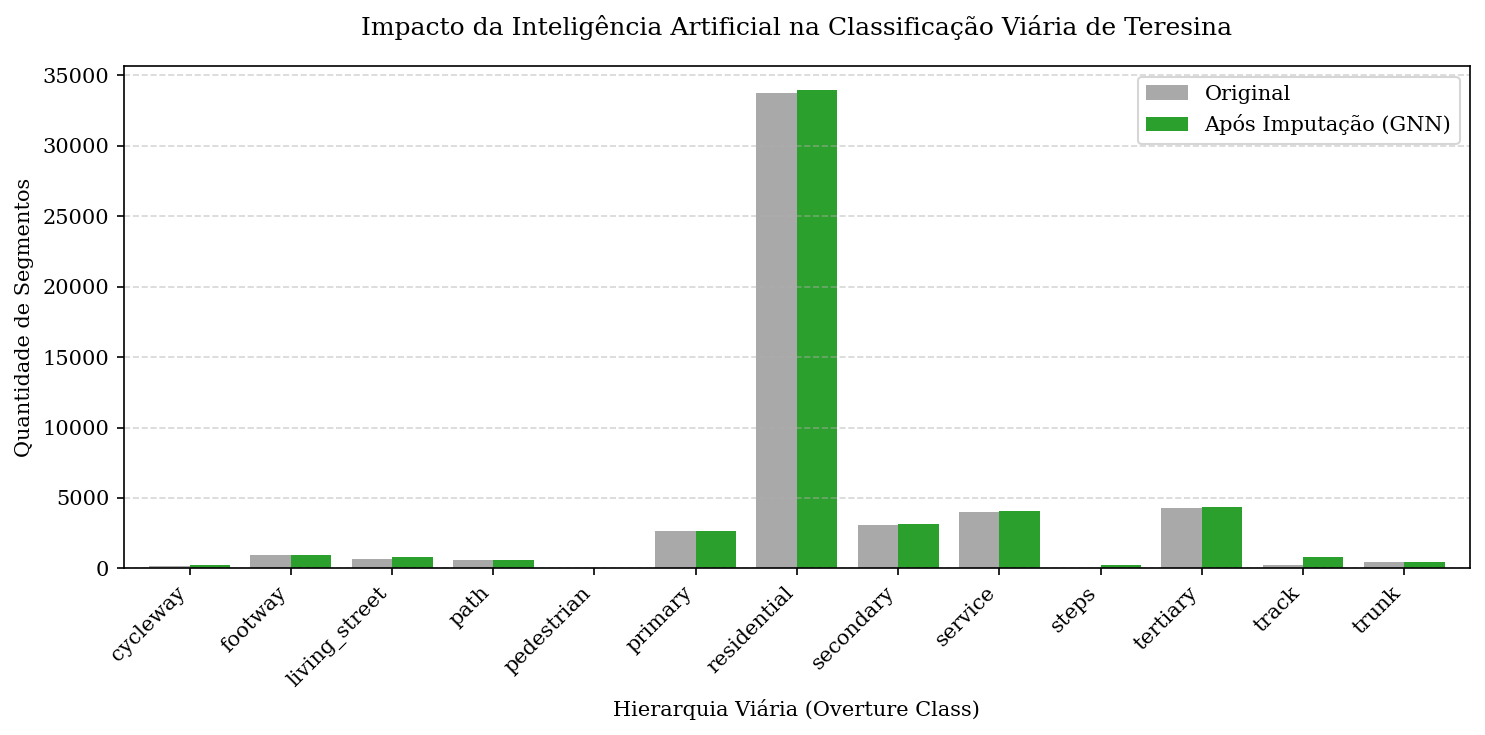

💾 Grafo final e 100% categorizado salvo em: ..\dados\processados\zonaUrbanaReal_5km_road_gnn_imputed.parquet


In [9]:
# ── 5. Avaliação de Impacto Visual e Exportação ─────────────────────────────

# O Resultado Visual Principal!
fig, ax = plt.subplots(figsize=(10, 5))

antes = gdf_roads['classe_original'].value_counts()
depois = gdf_roads['class'].value_counts()

df_plot = pd.DataFrame({'Original': antes, 'Após Imputação (GNN)': depois}).fillna(0)

# Removemos as classes nulas/desconhecidas do gráfico para focar nas categorias úteis imputadas
df_plot.drop(index=classes_invalidas, errors='ignore').plot(
    kind='bar', ax=ax, color=['#A9A9A9', '#2CA02C'], width=0.8
)

ax.set_title("Impacto da Inteligência Artificial na Classificação Viária de Teresina", pad=15)
ax.set_ylabel("Quantidade de Segmentos", fontsize=10)
ax.set_xlabel("Hierarquia Viária (Overture Class)", fontsize=10)
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_3_impacto_gnn.png')
plt.show()

# ── Exportação do Dataset Enriquecido (Pronto para roteamento) ──
caminho_final = PROCESSED_PATH / "zonaUrbanaReal_5km_road_gnn_imputed.parquet"

# Limpando colunas temporárias
gdf_roads.drop(columns=['id_unico_aresta', 'class_encoded'], inplace=True, errors='ignore')

gdf_roads.to_parquet(caminho_final, index=False)
print(f"💾 Grafo final e 100% categorizado salvo em: {caminho_final}")

### Fig. 4.6 — Mapa da malha viária por classe funcional

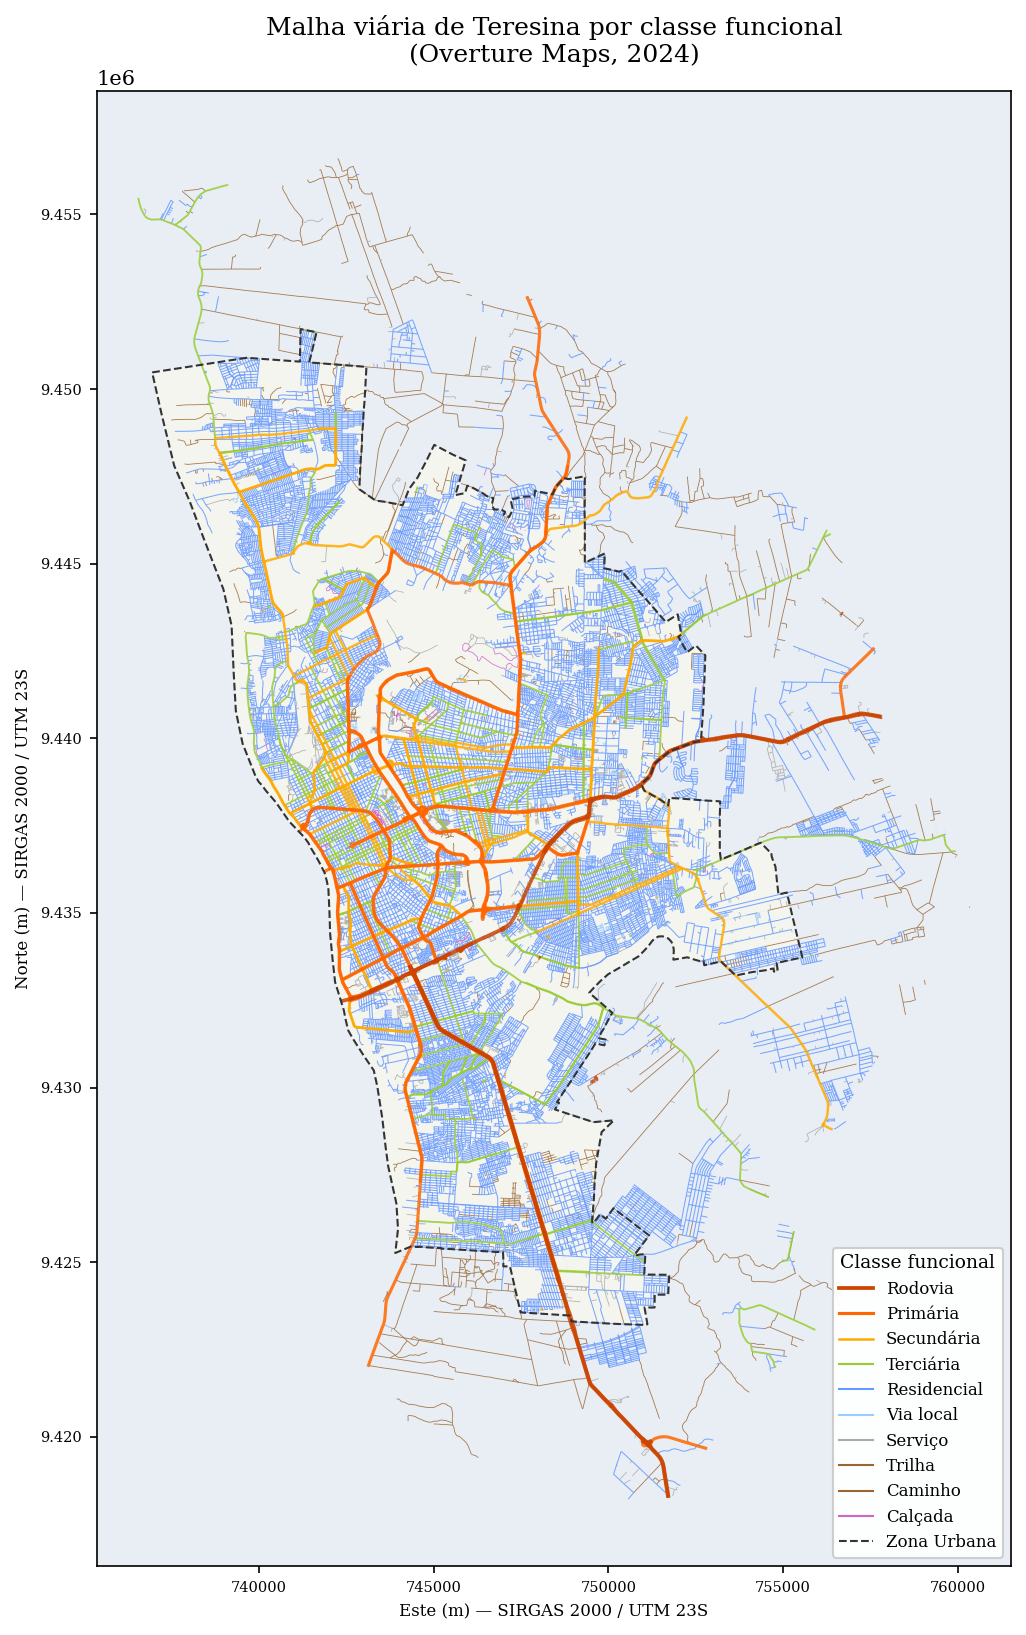

✅ Fig. 4.6 salva.


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Fig. 4.6 — Mapa da malha viária por classe funcional ─────────────────────
# Figura de referência cartográfica: apresenta a estrutura hierárquica da rede
# viária de Teresina. Evidencia a predominância de vias residenciais e a
# concentração de vias primárias/tronco no centro e nas radiais.

zu_gdf = gpd.read_parquet("../dados/brutos/ibge/teresina_zonaUrbana_utm.parquet")

CLASSES_MAPA = {
    'trunk'        : ('#CC4400', 1.8, 'Rodovia'),
    'primary'      : ('#FF6600', 1.5, 'Primária'),
    'secondary'    : ('#FFAA00', 1.2, 'Secundária'),
    'tertiary'     : ('#99CC33', 0.9, 'Terciária'),
    'residential'  : ('#6699FF', 0.5, 'Residencial'),
    'living_street': ('#99CCFF', 0.5, 'Via local'),
    'service'      : ('#AAAAAA', 0.4, 'Serviço'),
    'track'        : ('#996633', 0.4, 'Trilha'),
    'path'         : ('#996633', 0.4, 'Caminho'),
    'footway'      : ('#CC66CC', 0.4, 'Calçada'),
    'unclassified' : ('#FFAAAA', 0.4, 'Não classificada'),
    'unknown'      : ('#FF4444', 0.4, 'Desconhecida'),
}

fig, ax = plt.subplots(figsize=(11, 11))

# Fundo
zu_gdf.plot(ax=ax, color='#F5F5F0', edgecolor='none', zorder=0)

# Vias não mapeadas (residual)
gdf_roads[~gdf_roads['class'].isin(CLASSES_MAPA.keys())].plot(
    ax=ax, color='#DDDDDD', linewidth=0.3, zorder=1, alpha=0.4)

# Vias por classe (ordem: menos visíveis primeiro)
for cls, (cor, lw, label) in reversed(list(CLASSES_MAPA.items())):
    subset = gdf_roads[gdf_roads['class'] == cls]
    if len(subset) > 0:
        subset.plot(ax=ax, color=cor, linewidth=lw, zorder=2, alpha=0.85)

# Contorno da zona urbana
zu_gdf.boundary.plot(ax=ax, color='#333333', linewidth=1.0, linestyle='--', zorder=6)

# Legenda
legend_elements = [
    Line2D([0], [0], color=cor, linewidth=max(lw, 1), label=label)
    for cls, (cor, lw, label) in CLASSES_MAPA.items()
    if len(gdf_roads[gdf_roads['class'] == cls]) > 0
] + [Line2D([0], [0], color='#333333', linewidth=1, linestyle='--', label='Zona Urbana')]

ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          framealpha=0.95, title='Classe funcional', title_fontsize=9)

ax.set_title('Malha viária de Teresina por classe funcional\n(Overture Maps, 2024)',
             fontsize=12, pad=14)
ax.set_facecolor('#E8EEF4')
ax.set_xlabel('Este (m) — SIRGAS 2000 / UTM 23S', fontsize=8)
ax.set_ylabel('Norte (m) — SIRGAS 2000 / UTM 23S', fontsize=8)
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_6_mapa_classes_viarias.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Fig. 4.6 salva.')

### Fig. 4.7 — Mapa: vias sem classificação funcional (alvos da GNN)

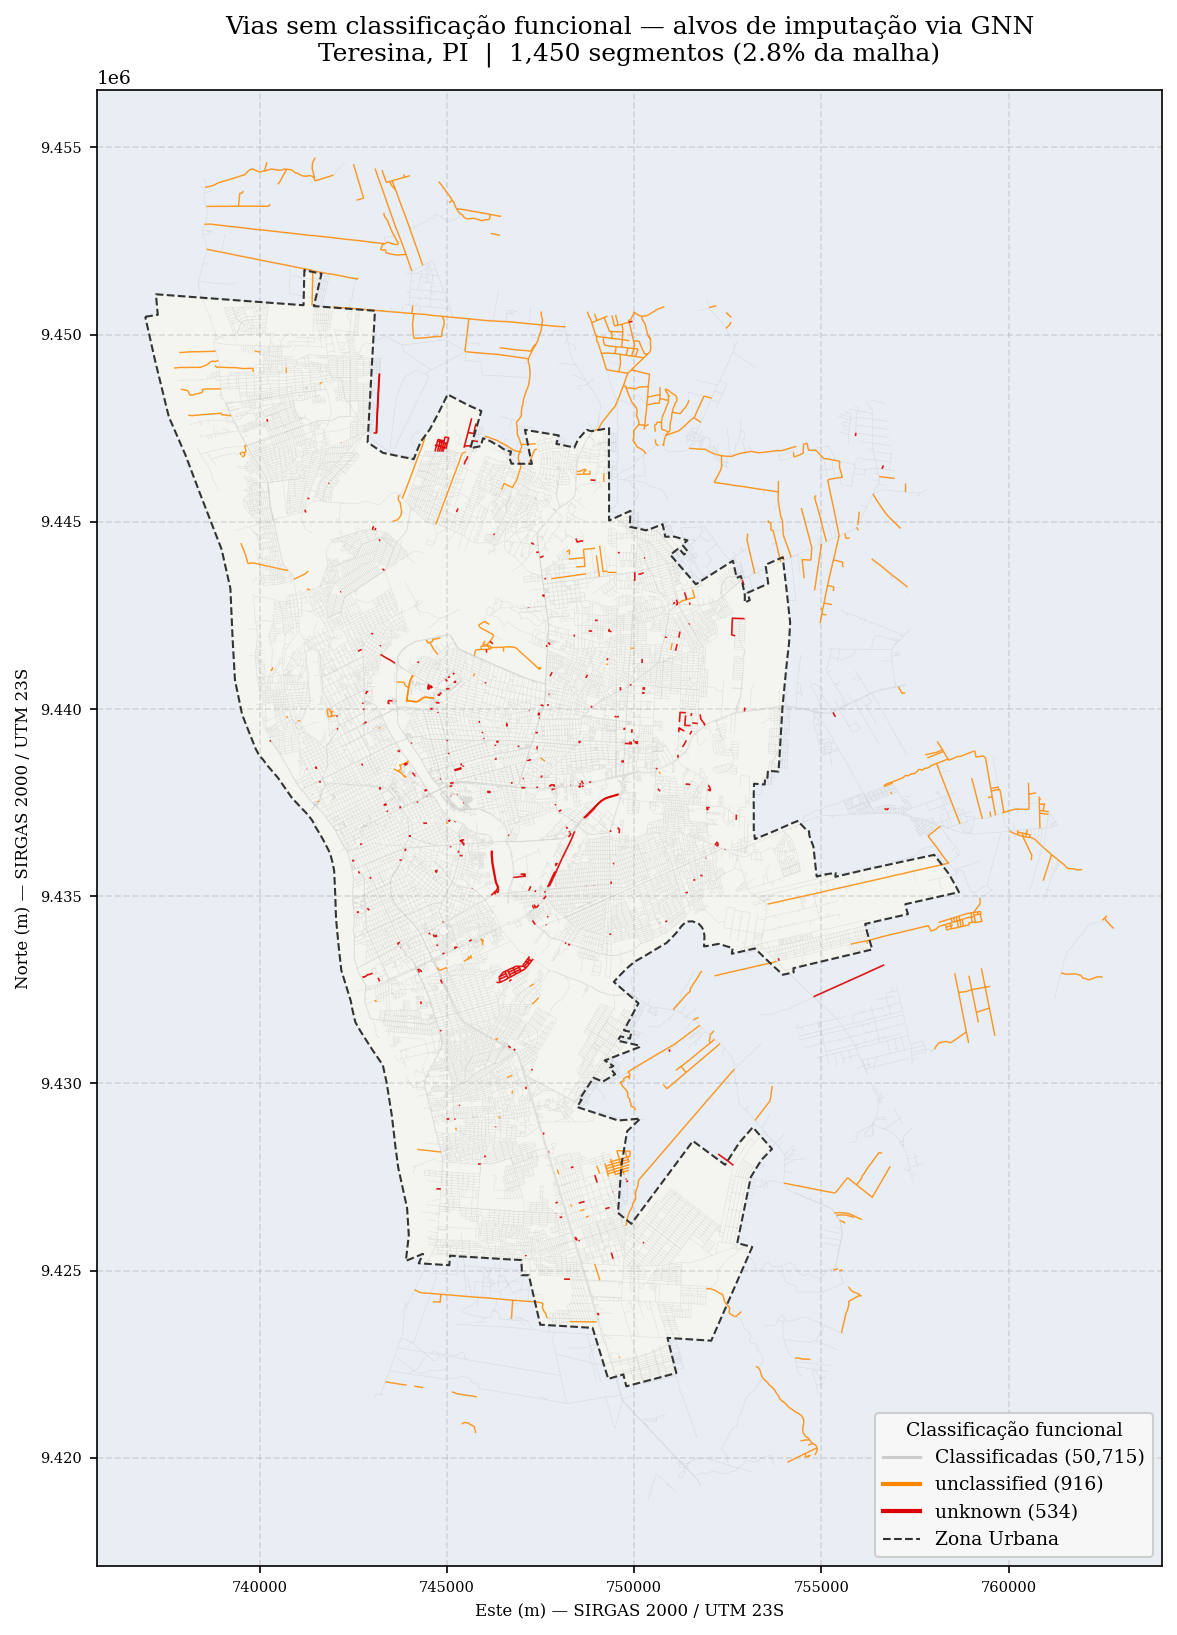

✅ Fig. 4.7 salva.


In [12]:
# ── Fig. 4.7 — Mapa de vias sem classificação ────────────────────────────────
# Fundamenta a necessidade da etapa GNN (NB 02.2): mostra onde estão os
# segmentos unknown e unclassified que não podem receber velocidade sem
# imputação de classe funcional. Concentração periférica dialoga com H2.

CLASSES_SEM = ['unknown', 'unclassified']

road_com    = road_process_barriers[~road_process_barriers['class'].isin(CLASSES_SEM)]
road_sem_uk = road_process_barriers[road_process_barriers['class'] == 'unknown']
road_sem_uc = road_process_barriers[road_process_barriers['class'] == 'unclassified']

n_sem = len(road_sem_uk) + len(road_sem_uc)

fig, ax = plt.subplots(figsize=(11, 11))

# Fundo
zu_gdf.plot(ax=ax, color='#F5F5F0', edgecolor='none', zorder=0)

# Vias classificadas (fundo discreto)
road_com.plot(ax=ax, color='#CCCCCC', linewidth=0.3, alpha=0.5, zorder=1)

# Vias sem classificação
road_sem_uc.plot(ax=ax, color='#FF8800', linewidth=0.7, alpha=0.85, zorder=3,
                 label=f'unclassified ({len(road_sem_uc):,})')
road_sem_uk.plot(ax=ax, color='#DD0000', linewidth=0.8, alpha=0.9, zorder=4,
                 label=f'unknown ({len(road_sem_uk):,})')

# Contorno ZU
zu_gdf.boundary.plot(ax=ax, color='#333333', linewidth=1.0, linestyle='--', zorder=6)

legend_elements = [
    Line2D([0], [0], color='#CCCCCC', linewidth=1.5, label=f'Classificadas ({len(road_com):,})'),
    Line2D([0], [0], color='#FF8800', linewidth=2,   label=f'unclassified ({len(road_sem_uc):,})'),
    Line2D([0], [0], color='#DD0000', linewidth=2,   label=f'unknown ({len(road_sem_uk):,})'),
    Line2D([0], [0], color='#333333', linewidth=1, linestyle='--', label='Zona Urbana'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          framealpha=0.95, title='Classificação funcional', title_fontsize=9)

ax.set_title(
    f'Vias sem classificação funcional — alvos de imputação via GNN\n'
    f'Teresina, PI  |  {n_sem:,} segmentos ({n_sem/len(road_process_barriers)*100:.1f}% da malha)',
    fontsize=12, pad=14
)
ax.set_facecolor('#E8EEF4')
ax.set_xlabel('Este (m) — SIRGAS 2000 / UTM 23S', fontsize=8)
ax.set_ylabel('Norte (m) — SIRGAS 2000 / UTM 23S', fontsize=8)
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(FIGURAS_PATH / 'fig4_7_mapa_alvos_gnn.png', dpi=300, bbox_inches='tight')
plt.show()
print('✅ Fig. 4.7 salva.')
